In [95]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

In [563]:
df = pd.read_csv("creditCardData.csv")
df.head()

,id,credit_limit,owned_rent,education,marriage,age,payment_status_1,payment_status_2,payment_status_3,due_amt1,due_amt2,due_amt3,payment_amt1,payment_amt2,payment_amt3,default
0,1,50000,1,3,2,25,-1,0,0,42838,37225,36087,1759,1779,320,0
1,2,360000,2,1,1,45,-1,-1,2,390,1170,780,1170,0,0,1
2,3,420000,1,2,1,34,0,0,0,253454,247743,229049,9744,9553,7603,0
3,4,190000,1,2,2,34,2,0,0,129801,131383,134379,5000,5000,10000,1
4,5,50000,1,1,2,39,0,0,0,47174,47974,48630,1800,2000,3000,0


In [564]:
df.shape

(600, 16)

In [565]:
df['default'].value_counts()

default
0    433
1    167
Name: count, dtype: int64

In [566]:
# Remove id column as it is for indexing purposes only
df = df.drop('id', axis=1)

In [567]:
df.describe()

,credit_limit,owned_rent,education,marriage,age,payment_status_1,payment_status_2,payment_status_3,due_amt1,due_amt2,due_amt3,payment_amt1,payment_amt2,payment_amt3,default
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000
mean,163950.000000,1.578333,1.876667,1.533333,36.215000,0.058333,-0.048333,-0.036667,54742.483333,54536.361667,50507.975000,6395.673333,5235.79000,5177.161667,0.278333
std,128834.109924,0.494238,0.743220,0.515751,9.178736,1.179229,1.245760,1.266753,75455.599323,75592.363514,72078.831178,16096.299870,12974.33437,18162.101849,0.448552
min,10000.000000,1.000000,1.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-7438.000000,-880.000000,-157264.000000,0.000000,0.00000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,29.000000,-1.000000,-1.000000,-1.000000,3994.000000,3495.750000,3039.250000,1000.000000,693.25000,390.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,35.000000,0.000000,0.000000,0.000000,25268.500000,25457.500000,20689.500000,2231.500000,2015.00000,1798.500000,0.000000
75%,230000.000000,2.000000,2.000000,2.000000,42.250000,1.000000,0.000000,0.000000,69042.750000,68250.750000,65000.000000,6000.000000,5000.00000,4475.500000,1.000000
max,720000.000000,2.000000,5.000000,3.000000,69.000000,8.000000,7.000000,7.000000,458652.000000,467150.000000,458862.000000,229818.000000,150042.00000,332809.000000,1.000000


In [568]:
# Investigating negtive values for due amount columns
df[(df['due_amt1'] < 0) | (df['due_amt2'] < 0) | (df['due_amt3'] < 0)]

,credit_limit,owned_rent,education,marriage,age,payment_status_1,payment_status_2,payment_status_3,due_amt1,due_amt2,due_amt3,payment_amt1,payment_amt2,payment_amt3,default
19,350000,1,1,2,33,-1,-1,-1,10900,10478,-22,10530,0,0,0
96,350000,2,2,1,33,-2,-2,-1,-7438,144562,147437,152000,6000,5000,0
120,200000,2,3,1,41,-2,-2,-2,-140,-70,-70,0,0,14038,0
141,200000,2,1,2,32,-1,-1,-1,146,-3,670,0,673,0,0
209,400000,1,1,1,44,-1,-1,-1,4482,-10,1903,0,1913,850,0
220,50000,1,2,2,27,0,0,0,26380,26439,-200,1000,0,0,0
222,500000,2,2,1,40,-1,-1,-1,2231,-9,2312,0,2321,2928,0
235,370000,2,1,2,28,-1,-1,-1,577,27895,-4247,63895,0,8694,0
253,200000,2,1,1,49,-1,-1,-2,4739,-61,-61,0,0,0,0
297,60000,1,1,2,31,1,-2,-2,0,-880,-2640,0,0,4400,1


In [569]:
# No. of rows affected
print(df[(df['due_amt1'] < 0) | (df['due_amt2'] < 0) | (df['due_amt3'] < 0)].shape[0])
# Negative values should not be removed as they possibly indicate overpayment/ credit refund

17


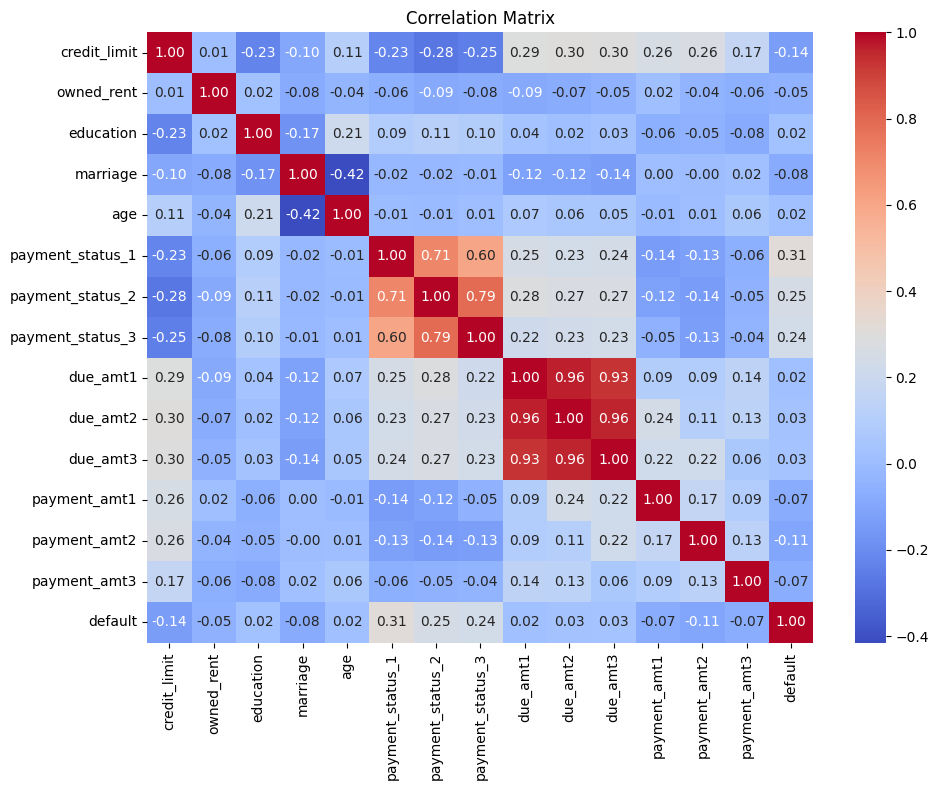

In [570]:
correlations = df.corr()['default'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Feature Engineering

#### Feature to capture recent payment timeliness

In [571]:
status1 = df['payment_status_1'].where(df['payment_status_1'] >= 0, np.nan)
status2 = df['payment_status_2'].where(df['payment_status_2'] >= 0, np.nan)
status3 = df['payment_status_3'].where(df['payment_status_3'] >= 0, np.nan)

df['worsening_delay'] = (
    (status1 > status2) |
    (status2 > status3)
).fillna(False).astype(int)

In [572]:
df['is_delay'] = ((df['payment_status_1'] > 0) | (df['payment_status_2'] > 0) | (df['payment_status_3'] > 0)).astype(int)

#### Feature to capture debt exposure

In [573]:
df['latest_debt_to_credit_ratio'] =  df['due_amt1'] / df['credit_limit']

#### Interaction feature to capture demographic information

In [574]:
df['age x credit_limit'] = df['age'] * df['credit_limit']

## Splitting Data

In [607]:
X = df.drop(columns = ['default'])
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test) 

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [576]:
X_train_scaled.head()

,credit_limit,owned_rent,education,marriage,age,payment_status_1,payment_status_2,payment_status_3,due_amt1,due_amt2,due_amt3,payment_amt1,payment_amt2,payment_amt3,worsening_delay,is_delay,latest_debt_to_credit_ratio,age x credit_limit
276,-0.119474,0.820045,-1.169926,0.908948,-0.007990,-0.026245,0.018132,-1.531342,-0.530116,-0.730540,-0.716904,-0.385949,-0.393940,-0.364225,-0.305604,-0.664411,-0.819324,-0.132276
234,-0.509065,0.820045,1.556115,-1.047532,0.320732,-0.026245,0.018132,0.016119,-0.210740,-0.196929,-0.137947,-0.290907,-0.272465,-0.253032,-0.305604,-0.664411,-0.141236,-0.412465
302,-0.353229,0.820045,0.193095,0.908948,-1.213304,0.813595,-1.564297,-1.531342,-0.733807,-0.730540,-0.716904,-0.385949,-0.393940,-0.364225,-0.305604,1.505093,-1.057090,-0.580578
546,-0.664901,-1.219445,1.556115,-1.047532,-0.555860,-0.026245,0.018132,0.016119,0.124473,0.124202,0.143094,-0.213041,-0.101757,-0.137455,-0.305604,-0.664411,0.821395,-0.677710
55,-1.054491,0.820045,-1.169926,0.908948,-0.994156,1.653435,1.600561,1.563581,-0.361856,-0.346942,-0.321426,-0.282204,-0.393940,-0.201707,-0.305604,1.505093,1.113773,-0.989653


## Standard Logistic Regression

                        feature      coef  odds_ratio
15                     is_delay  0.451261    1.570291
17           age x credit_limit  0.362555    1.436997
9                      due_amt2  0.359419    1.432498
5              payment_status_1  0.258774    1.295341
10                     due_amt3  0.190390    1.209721
6              payment_status_2  0.124863    1.132994
14              worsening_delay  0.021066    1.021290
4                           age -0.050722    0.950543
11                 payment_amt1 -0.079816    0.923286
13                 payment_amt3 -0.090663    0.913325
2                     education -0.095028    0.909348
7              payment_status_3 -0.095792    0.908653
1                    owned_rent -0.117910    0.888776
16  latest_debt_to_credit_ratio -0.158082    0.853780
3                      marriage -0.263361    0.768465
12                 payment_amt2 -0.351374    0.703720
8                      due_amt1 -0.367390    0.692539
0                  credit_li

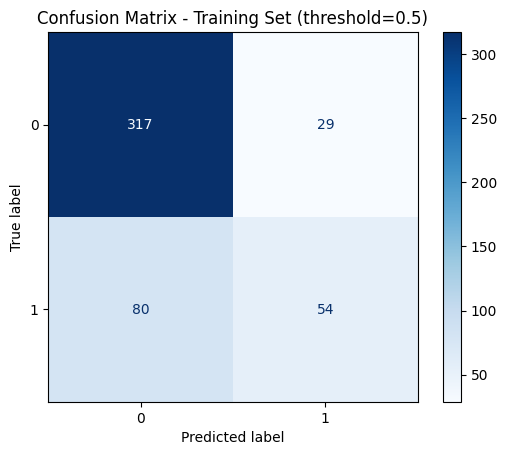

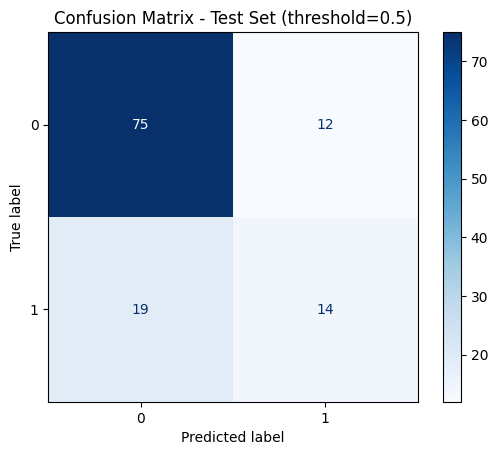

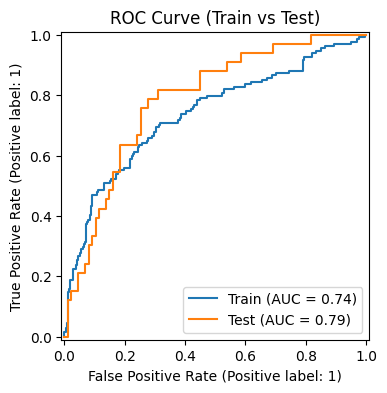

In [608]:
standard_logreg = LogisticRegression(max_iter=10000, random_state=42)
standard_logreg.fit(X_train_scaled, y_train)

# Coefficients and odds ratios
coef = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coef': standard_logreg.coef_[0],
    'odds_ratio': np.exp(standard_logreg.coef_[0])
}).sort_values(by='odds_ratio', ascending=False)
print(coef)

# Function to generate predictions at custom threshold
def predict_with_threshold(model, X, threshold=0.5):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return y_pred, y_proba

# Full model report with custom threshold
def full_model_report(y_true, y_pred, y_proba):
    print(classification_report(y_true, y_pred))
    
    auc = roc_auc_score(y_true, y_proba)
    print(f"Test AUC Score: {auc:.3f}\n")
    
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)
    FPR = FP / (FP + TN)
    FNR = FN / (TP + FN)
    precision = TP / (TP + FP)
    
    print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"TPR (Recall): {TPR:.3f}")
    print(f"TNR (Specificity): {TNR:.3f}")
    print(f"FPR: {FPR:.3f}")
    print(f"FNR: {FNR:.3f}")
    print(f"Precision: {precision:.3f}")

threshold = 0.5

standard_y_pred, standard_y_proba = predict_with_threshold(standard_logreg, X_test_scaled, threshold=threshold)

print(f"\n{'='*50}")
print(f"Model Evaluation with Threshold = {threshold}")
print(f"{'='*50}\n")
full_model_report(y_test, standard_y_pred, standard_y_proba)

train_y_pred, _ = predict_with_threshold(standard_logreg, X_train_scaled, threshold=threshold)

# Confusion matrices
cm_train = confusion_matrix(y_train, train_y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_train).plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Training Set (threshold={threshold})")
plt.show()

cm_test = confusion_matrix(y_test, standard_y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_test).plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Test Set (threshold={threshold})")
plt.show()

# ROC Curve
train_disp = RocCurveDisplay.from_estimator(standard_logreg, X_train_scaled, y_train, name="Train")
RocCurveDisplay.from_estimator(standard_logreg, X_test_scaled, y_test, ax=train_disp.ax_, name="Test")
plt.gcf().set_size_inches(10, 4)
plt.title("ROC Curve (Train vs Test)")
plt.show()

## Feature Selection

### Forward Stepwise Selection (Sequential Feature Selector)

Step  1 | CV AUC = 0.6708 (±0.0435) | Added: is_delay
→ Current features: ['is_delay']

Step  2 | CV AUC = 0.6983 (±0.0665) | Added: credit_limit
→ Current features: ['credit_limit', 'is_delay']

Step  3 | CV AUC = 0.7031 (±0.0616) | Added: marriage
→ Current features: ['credit_limit', 'marriage', 'is_delay']

Step  4 | CV AUC = 0.7047 (±0.0617) | Added: age x credit_limit
→ Current features: ['credit_limit', 'marriage', 'is_delay', 'age x credit_limit']

Step  5 | CV AUC = 0.7042 (±0.0629) | Added: payment_amt2
→ Current features: ['credit_limit', 'marriage', 'payment_amt2', 'is_delay', 'age x credit_limit']

Step  6 | CV AUC = 0.7046 (±0.0617) | Added: payment_amt3
→ Current features: ['credit_limit', 'marriage', 'payment_amt2', 'payment_amt3', 'is_delay', 'age x credit_limit']

Step  7 | CV AUC = 0.7013 (±0.0599) | Added: education
→ Current features: ['credit_limit', 'education', 'marriage', 'payment_amt2', 'payment_amt3', 'is_delay', 'age x credit_limit']

Step  8 | CV AUC = 0.698

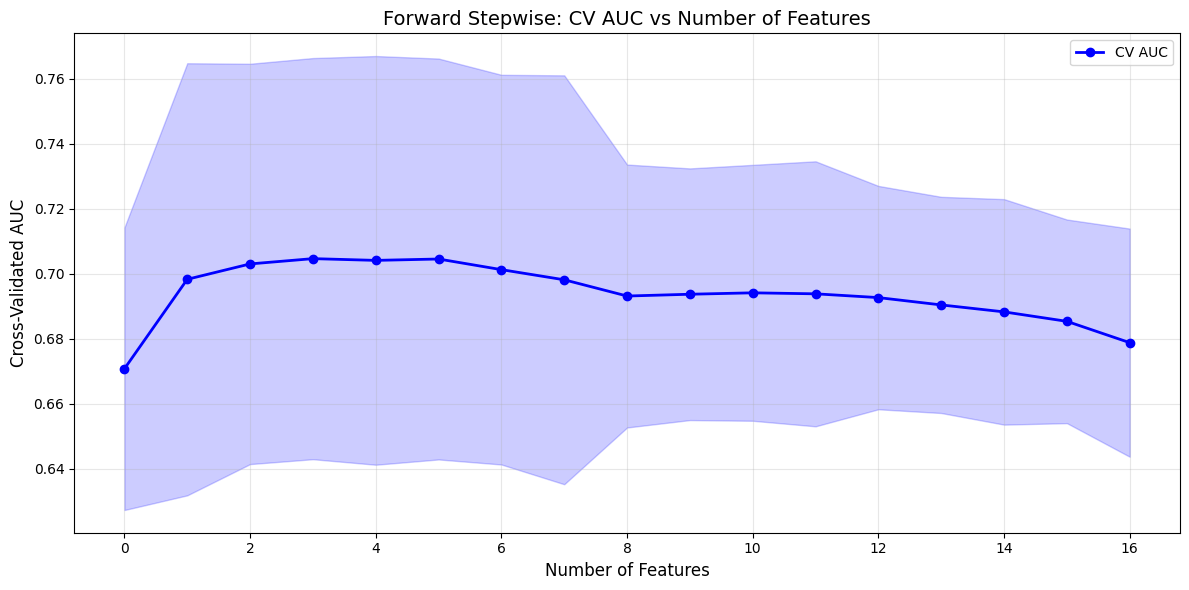


Step-by-step feature selection results:
    n_features    cv_auc    cv_std                added_feature
0            0  0.670807  0.043454                     is_delay
1            1  0.698336  0.066468                 credit_limit
2            2  0.703066  0.061579                     marriage
3            3  0.704692  0.061706           age x credit_limit
4            4  0.704156  0.062867                 payment_amt2
5            5  0.704577  0.061666                 payment_amt3
6            6  0.701304  0.059943                    education
7            7  0.698183  0.062898                 payment_amt1
8            8  0.693188  0.040444                     due_amt3
9            9  0.693740  0.038713             payment_status_1
10          10  0.694174  0.039364             payment_status_2
11          11  0.693867  0.040764  latest_debt_to_credit_ratio
12          12  0.692707  0.034356                   owned_rent
13          13  0.690452  0.033255              worsening_delay

In [579]:
def forward_stepwise_selection(
    X_train, y_train, 
    estimator=None, 
    cv=10, 
    verbose=True,
    scoring='roc_auc',
    random_state=42,
):
    
    if estimator is None:
        estimator = LogisticRegression(
            max_iter=10000, solver='liblinear', random_state=random_state
        )
    
    n_features_max = X_train.shape[1] - 1
    cv_scores = []
    cv_std = []
    feature_history = []
    added_features = [] 
    
    
    for n in range(1, n_features_max + 1):
        sfs = SequentialFeatureSelector(
            estimator,
            n_features_to_select=n,
            direction='forward',
            scoring=scoring,
            cv=cv,
            n_jobs=-1
        )
        sfs.fit(X_train, y_train)
        
        selected = X_train.columns[sfs.get_support()].tolist()
        feature_history.append(selected)
        
        # NEW: Get CV scores with mean and std
        cv_auc_scores = cross_val_score(
            estimator, X_train[selected], y_train, cv=cv, scoring=scoring
        )
        cv_mean = cv_auc_scores.mean()
        cv_std_dev = cv_auc_scores.std()
        
        cv_scores.append(cv_mean)
        cv_std.append(cv_std_dev)
        
        if n == 1:
            added_feature = selected[0]
        else:
            added_feature = list(set(selected) - set(feature_history[-2]))[0]
        added_features.append(added_feature)
        
        if verbose:
            print(f"Step {n:2d} | CV AUC = {cv_mean:.4f} (±{cv_std_dev:.4f}) | Added: {added_feature}")
            print(f"→ Current features: {selected}\n")
    
    results = pd.DataFrame({
        'n_features': range(0, n_features_max),
        'cv_auc': cv_scores,
        'cv_std': cv_std,
        'added_feature': added_features,
        'features': feature_history})
    
    plt.figure(figsize=(12, 6))
    plt.plot(results['n_features'], results['cv_auc'], 'b-o', linewidth=2, label='CV AUC')
    plt.fill_between(results['n_features'], 
                     results['cv_auc'] - results['cv_std'], 
                     results['cv_auc'] + results['cv_std'], 
                     alpha=0.2, color='blue')
    
    plt.xlabel('Number of Features', fontsize=12)
    plt.ylabel('Cross-Validated AUC', fontsize=12)
    plt.title('Forward Stepwise: CV AUC vs Number of Features', fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return results, best_features

results, best_features = forward_stepwise_selection(X_train_scaled, y_train, cv=5)
print("\nStep-by-step feature selection results:")
print(results[['n_features', 'cv_auc', 'cv_std', 'added_feature']])

12 features selected:
['credit_limit', 'education', 'marriage', 'payment_status_1', 'payment_status_2', 'due_amt3', 'payment_amt1', 'payment_amt2', 'payment_amt3', 'worsening_delay', 'is_delay', 'age x credit_limit']
               feature      coef  odds_ratio
10            is_delay  0.487850    1.628811
11  age x credit_limit  0.265301    1.303823
3     payment_status_1  0.164805    1.179163
5             due_amt3  0.115369    1.122287
9      worsening_delay  0.057826    1.059530
4     payment_status_2  0.026708    1.027068
6         payment_amt1 -0.039245    0.961515
1            education -0.094551    0.909781
8         payment_amt3 -0.101074    0.903866
2             marriage -0.234756    0.790764
7         payment_amt2 -0.275276    0.759363
0         credit_limit -0.403102    0.668244
              precision    recall  f1-score   support

           0       0.86      0.77      0.81        87
           1       0.52      0.67      0.59        33

    accuracy                      

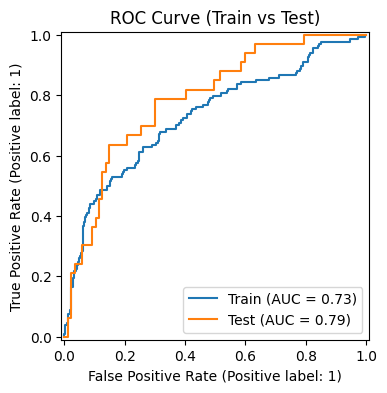

In [630]:
forward_features = ['credit_limit', 'education', 'marriage', 'payment_status_1', 'payment_status_2', 'due_amt3', 'payment_amt1', 'payment_amt2', 'payment_amt3', 'worsening_delay', 'is_delay', 'age x credit_limit']
forward_logreg = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')
forward_logreg.fit(X_train_scaled[forward_features], y_train)
forward_y_pred = forward_logreg.predict(X_test_scaled[forward_features])
forward_y_proba = forward_logreg.predict_proba(X_test_scaled[forward_features])[:,1]
coef = pd.DataFrame({
    'feature': X_train_scaled[forward_features].columns,
    'coef': forward_logreg.coef_[0],
    'odds_ratio': np.exp(forward_logreg.coef_[0])
}).sort_values(by='odds_ratio', ascending=False)
print(str(len(forward_features)) + " features selected:" )
print(forward_features)
print(coef)
full_model_report(y_test, forward_y_pred, forward_y_proba)
train_disp = skm.RocCurveDisplay.from_estimator(forward_logreg, X_train_scaled[forward_features], y_train, name="Train")
skm.RocCurveDisplay.from_estimator(forward_logreg, X_test_scaled[forward_features], y_test, ax=train_disp.ax_, name="Test")
plt.gcf().set_size_inches(10, 4)
plt.title("ROC Curve (Train vs Test)")
plt.show()

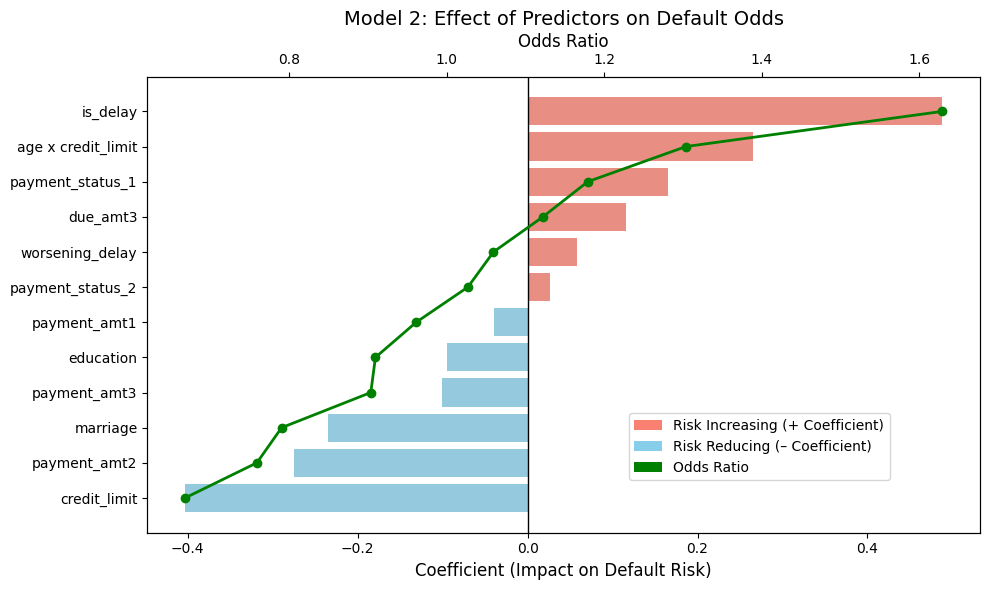

In [652]:
coef_sorted = coef.sort_values(by='coef', ascending=False).copy()
coef_sorted['effect'] = np.where(coef_sorted['coef'] > 0, 'Risk Increasing', 'Risk Reducing')

plt.figure(figsize=(10, 6))
ax1 = plt.gca()

sns.barplot(
    x='coef',
    y='feature',
    hue='effect',
    data=coef_sorted,
    palette={'Risk Increasing': 'salmon', 'Risk Reducing': 'skyblue'},
    dodge=False,
    legend=False
)

ax1.axvline(x=0, color='black', linewidth=1)
ax1.set_xlabel('Coefficient (Impact on Default Risk)', fontsize=12)
ax1.set_ylabel('')
ax1.set_title('Model 2: Effect of Predictors on Default Odds', fontsize=14)

ax2 = ax1.twiny()
ax2.plot(coef_sorted['odds_ratio'], coef_sorted['feature'], color='green', marker='o', linewidth=2, label='Odds Ratio')
ax2.set_xlabel('Odds Ratio', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='salmon', label='Risk Increasing (+ Coefficient)'),
    Patch(facecolor='skyblue', label='Risk Reducing (– Coefficient)'),
    Patch(facecolor='green', label='Odds Ratio', edgecolor='none')
]
ax1.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.9, 0.1))

plt.tight_layout()
plt.show()


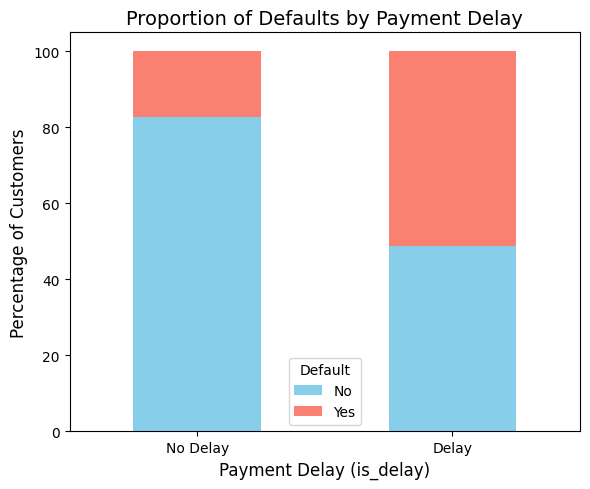

In [636]:
delay_default_counts = df.groupby(['is_delay', 'default']).size().reset_index(name='count')
delay_default_pivot = delay_default_counts.pivot(index='is_delay', columns='default', values='count').fillna(0)
delay_default_pct = delay_default_pivot.div(delay_default_pivot.sum(axis=1), axis=0) * 100
ax = delay_default_pct.plot(kind='bar', stacked=True, figsize=(6,5), color=['skyblue', 'salmon'])

plt.xticks(ticks=[0,1], labels=['No Delay', 'Delay'], rotation=0)
plt.xlabel('Payment Delay (is_delay)', fontsize=12)
plt.ylabel('Percentage of Customers', fontsize=12)
plt.title('Proportion of Defaults by Payment Delay', fontsize=14)
plt.legend(title='Default', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

C:\Users\lecia\AppData\Local\Temp\ipykernel_27956\3153613342.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = df.groupby(['age_bin', 'credit_bin']).agg(


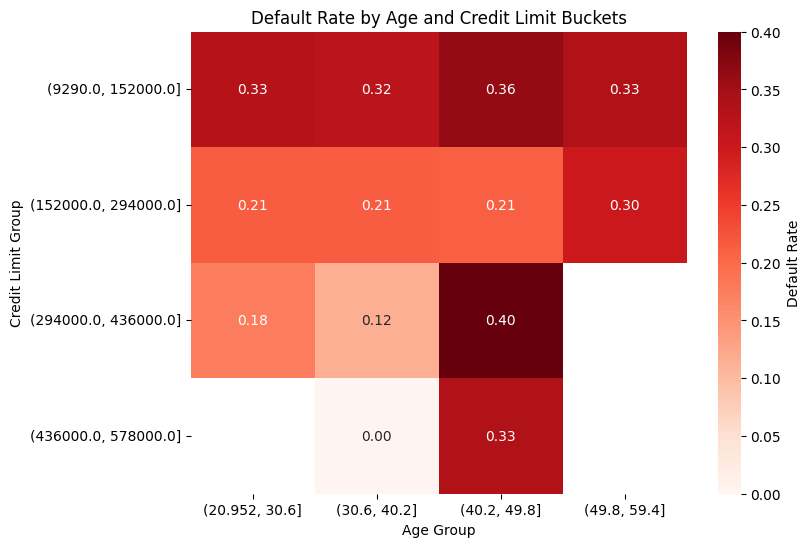

In [656]:
# Bin age and credit limit into buckets
df['age_bin'] = pd.cut(df['age'], bins=5)
df['credit_bin'] = pd.cut(df['credit_limit'], bins=5)

# Compute default rate and count in each bucket
bucket_stats = df.groupby(['age_bin', 'credit_bin']).agg(
    default_rate=('default', 'mean'),
    count=('default', 'size')
).reset_index()

# Filter out bins with less than 2 data points
bucket_stats = bucket_stats[bucket_stats['count'] > 5]

# Pivot for heatmap
heatmap_df = bucket_stats.pivot(index='credit_bin', columns='age_bin', values='default_rate')

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap='Reds',
    cbar_kws={'label': 'Default Rate'}
)
plt.xlabel('Age Group')
plt.ylabel('Credit Limit Group')
plt.title('Default Rate by Age and Credit Limit Buckets')
plt.show()


### Lasso Regularisation for Feature Selection

In [587]:
def lasso_feature_path(X, y, C_values=None, cv=5, random_state=42):
    if C_values is None:
        C_values = np.arange(0.1, 1.5, 0.1)

    coef_data = []
    train_scores = []
    cv_scores = []
    cv_std = []
    features = X.columns

    for C in C_values:
        logreg = LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=C,
            max_iter=5000,
            random_state=random_state
        )
        logreg.fit(X, y)

        coefs = logreg.coef_[0]
        selected = features[coefs != 0].tolist()

        train_auc = roc_auc_score(y, logreg.predict_proba(X)[:, 1])
        
        cv_auc_scores = cross_val_score(
            logreg, X, y, cv=cv, scoring='roc_auc', n_jobs=-1
        )
        cv_mean = cv_auc_scores.mean()
        cv_std_dev = cv_auc_scores.std()
        
        coef_data.append(coefs)
        train_scores.append(train_auc)
        cv_scores.append(cv_mean)
        cv_std.append(cv_std_dev) 

        print(f"C = {C:<7.4f} | Train AUC = {train_auc:.4f} | CV AUC = {cv_mean:.4f} (±{cv_std_dev:.4f}) | Selected {len(selected):>2} features:")
        print(f"→ {selected if selected else 'None selected'}\n")

    coef_df = pd.DataFrame(coef_data, columns=features, index=C_values)
    auc_df = pd.DataFrame({
        'C': C_values, 
        'Train_AUC': train_scores,
        'CV_AUC': cv_scores,
        'CV_std': cv_std})

    best_cv_idx = np.argmax(cv_scores)
    best_cv_auc = cv_scores[best_cv_idx]
    best_c = C_values[best_cv_idx]
    best_features = features[coef_data[best_cv_idx] != 0].tolist()

    return coef_df, auc_df

C = 0.1000  | Train AUC = 0.7145 | CV AUC = 0.6834 (±0.0349) | Selected  7 features:
→ ['credit_limit', 'owned_rent', 'marriage', 'payment_status_1', 'payment_status_2', 'payment_amt2', 'is_delay']

C = 0.2000  | Train AUC = 0.7171 | CV AUC = 0.6835 (±0.0373) | Selected  9 features:
→ ['credit_limit', 'owned_rent', 'marriage', 'payment_status_1', 'payment_status_2', 'payment_amt2', 'payment_amt3', 'worsening_delay', 'is_delay']

C = 0.3000  | Train AUC = 0.7202 | CV AUC = 0.6783 (±0.0415) | Selected 10 features:
→ ['credit_limit', 'owned_rent', 'education', 'marriage', 'payment_status_1', 'payment_status_2', 'payment_amt2', 'payment_amt3', 'worsening_delay', 'is_delay']

C = 0.4000  | Train AUC = 0.7228 | CV AUC = 0.6764 (±0.0411) | Selected 13 features:
→ ['credit_limit', 'owned_rent', 'education', 'marriage', 'payment_status_1', 'payment_status_2', 'due_amt2', 'due_amt3', 'payment_amt2', 'payment_amt3', 'worsening_delay', 'is_delay', 'latest_debt_to_credit_ratio']

C = 0.5000  | Trai

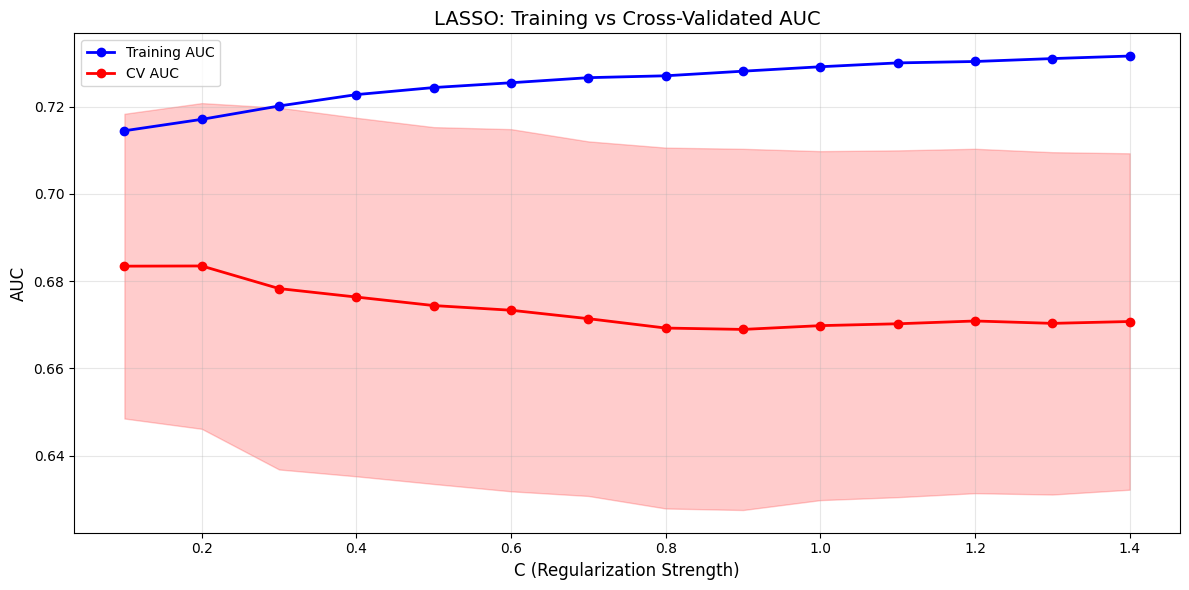

In [588]:
from sklearn.model_selection import cross_val_score

coef_df, auc_df = lasso_feature_path(X_train_scaled, y_train, cv=5)

plt.figure(figsize=(12, 6))
plt.plot(auc_df['C'], auc_df['Train_AUC'], 'b-o', label='Training AUC', linewidth=2)
plt.plot(auc_df['C'], auc_df['CV_AUC'], 'r-o', label='CV AUC', linewidth=2)
plt.fill_between(auc_df['C'], 
                 auc_df['CV_AUC'] - auc_df['CV_std'], 
                 auc_df['CV_AUC'] + auc_df['CV_std'], 
                 alpha=0.2, color='red')
plt.xlabel('C (Regularization Strength)', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.title('LASSO: Training vs Cross-Validated AUC', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

9 features selected using Lasso Regularisation:
['credit_limit', 'owned_rent', 'marriage', 'payment_status_1', 'payment_status_2', 'payment_amt2', 'payment_amt3', 'worsening_delay', 'is_delay']
            feature      coef  odds_ratio
8          is_delay  0.466063    1.593708
3  payment_status_1  0.206342    1.229174
7   worsening_delay  0.055954    1.057549
4  payment_status_2  0.054670    1.056192
6      payment_amt3 -0.073299    0.929323
0      credit_limit -0.087353    0.916353
1        owned_rent -0.136174    0.872691
5      payment_amt2 -0.250123    0.778705
2          marriage -0.254070    0.775637
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        87
           1       0.50      0.67      0.57        33

    accuracy                           0.72       120
   macro avg       0.68      0.71      0.68       120
weighted avg       0.76      0.72      0.74       120

Test AUC Score: 0.778

TP: 22, TN: 65, FP: 22, FN: 11
Accur

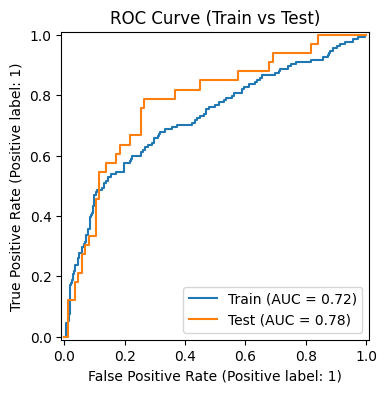

In [595]:
lasso_features = ['credit_limit', 'owned_rent', 'marriage', 'payment_status_1', 'payment_status_2', 
                  'payment_amt2', 'payment_amt3', 'worsening_delay', 'is_delay']
lasso_logreg = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')
lasso_logreg.fit(X_train_scaled[lasso_features], y_train)
lasso_y_pred = lasso_logreg.predict(X_test_scaled[lasso_features])
lasso_y_proba = lasso_logreg.predict_proba(X_test_scaled[lasso_features])[:,1]
coef = pd.DataFrame({
    'feature': X_train_scaled[lasso_features].columns,
    'coef': lasso_logreg.coef_[0],
    'odds_ratio': np.exp(lasso_logreg.coef_[0])
}).sort_values(by='odds_ratio', ascending=False)

print(str(len(lasso_features)) + " features selected using Lasso Regularisation:" )
print(lasso_features)
print(coef)
full_model_report(y_test, lasso_y_pred, lasso_y_proba)
train_disp = skm.RocCurveDisplay.from_estimator(lasso_logreg, X_train_scaled[lasso_features], y_train, name="Train")
skm.RocCurveDisplay.from_estimator(lasso_logreg, X_test_scaled[lasso_features], y_test, ax=train_disp.ax_, name="Test")
plt.gcf().set_size_inches(10, 4)
plt.title("ROC Curve (Train vs Test)")
plt.show()

## Ridge Regression

                        feature      coef  odds_ratio
15                     is_delay  0.451261    1.570291
17           age x credit_limit  0.362555    1.436997
9                      due_amt2  0.359419    1.432498
5              payment_status_1  0.258774    1.295341
10                     due_amt3  0.190390    1.209721
6              payment_status_2  0.124863    1.132994
14              worsening_delay  0.021066    1.021290
4                           age -0.050722    0.950543
11                 payment_amt1 -0.079816    0.923286
13                 payment_amt3 -0.090663    0.913325
2                     education -0.095028    0.909348
7              payment_status_3 -0.095792    0.908653
1                    owned_rent -0.117910    0.888776
16  latest_debt_to_credit_ratio -0.158082    0.853780
3                      marriage -0.263361    0.768465
12                 payment_amt2 -0.351374    0.703720
8                      due_amt1 -0.367390    0.692539
0                  credit_li

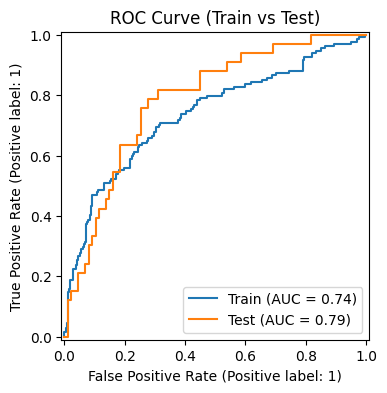

In [596]:
# Full set of features
ridge_logreg = LogisticRegression(max_iter=10000, random_state=42)
ridge_logreg.fit(X_train_scaled, y_train)
ridge_y_pred = ridge_logreg.predict(X_test_scaled)
ridge_y_proba = ridge_logreg.predict_proba(X_test_scaled)[:,1]
coef = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coef': ridge_logreg.coef_[0],
    'odds_ratio': np.exp(ridge_logreg.coef_[0])
}).sort_values(by='odds_ratio', ascending=False)

print(coef)
full_model_report(y_test, ridge_y_pred, ridge_y_proba)
train_disp = skm.RocCurveDisplay.from_estimator(ridge_logreg, X_train_scaled, y_train, name="Train")
skm.RocCurveDisplay.from_estimator(ridge_logreg, X_test_scaled, y_test, ax=train_disp.ax_, name="Test")
plt.gcf().set_size_inches(10, 4)
plt.title("ROC Curve (Train vs Test)")
plt.show()

In [601]:
l2_logreg = LogisticRegression(
    max_iter=10000,
    random_state=42,
    penalty='l2',
    solver='liblinear')

param_grid = {
    'C': [0.1, 0.5, 1, 2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=l2_logreg,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best C:", grid_search.best_params_)
print("Best cross-validated AUC:", grid_search.best_score_)

l2_logreg = grid_search.best_estimator_
l2_logreg.fit(X_train_scaled, y_train)

coef = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coef': l2_logreg.coef_[0],
    'odds_ratio': np.exp(l2_logreg.coef_[0])
}).sort_values(by='odds_ratio', ascending=False)
print(coef)

l2_y_pred = l2_logreg.predict(X_test_scaled)
l2_y_proba = l2_logreg.predict_proba(X_test_scaled)[:,1]

full_model_report(y_test, l2_y_pred, l2_y_proba)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: {'C': 10}
Best cross-validated AUC: 0.6743163867801548
                        feature      coef  odds_ratio
17           age x credit_limit  0.634781    1.886609
9                      due_amt2  0.589321    1.802764
15                     is_delay  0.457885    1.580727
5              payment_status_1  0.259504    1.296287
10                     due_amt3  0.222248    1.248882
6              payment_status_2  0.132466    1.141641
14              worsening_delay  0.013350    1.013440
13                 payment_amt3 -0.091621    0.912451
2                     education -0.095842    0.908608
4                           age -0.107946    0.897676
7              payment_status_3 -0.116206    0.890292
1                    owned_rent -0.116936    0.889642
11                 payment_amt1 -0.122860    0.884388
16  latest_debt_to_credit_ratio -0.154195    0.857104
3                      marriage -0.265985    0.766451
12           

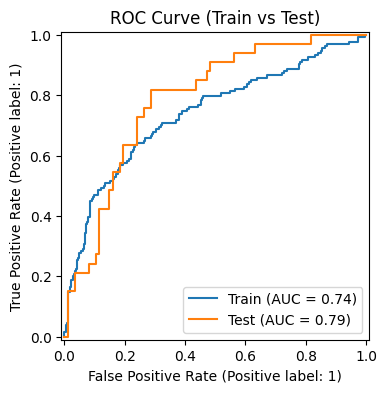

In [602]:
train_disp = skm.RocCurveDisplay.from_estimator(l2_logreg, X_train_scaled, y_train, name="Train")
skm.RocCurveDisplay.from_estimator(l2_logreg, X_test_scaled, y_test, ax=train_disp.ax_, name="Test")
plt.gcf().set_size_inches(10, 4)
plt.title("ROC Curve (Train vs Test)")
plt.show()

               feature      coef  odds_ratio
10            is_delay  0.487850    1.628811
11  age x credit_limit  0.265301    1.303823
3     payment_status_1  0.164805    1.179163
5             due_amt3  0.115369    1.122287
9      worsening_delay  0.057826    1.059530
4     payment_status_2  0.026708    1.027068
6         payment_amt1 -0.039245    0.961515
1            education -0.094551    0.909781
8         payment_amt3 -0.101074    0.903866
2             marriage -0.234756    0.790764
7         payment_amt2 -0.275276    0.759363
0         credit_limit -0.403102    0.668244
              precision    recall  f1-score   support

           0       0.86      0.77      0.81        87
           1       0.52      0.67      0.59        33

    accuracy                           0.74       120
   macro avg       0.69      0.72      0.70       120
weighted avg       0.77      0.74      0.75       120

Test AUC Score: 0.788

TP: 22, TN: 67, FP: 20, FN: 11
Accuracy: 0.742
TPR (Recall): 0.66

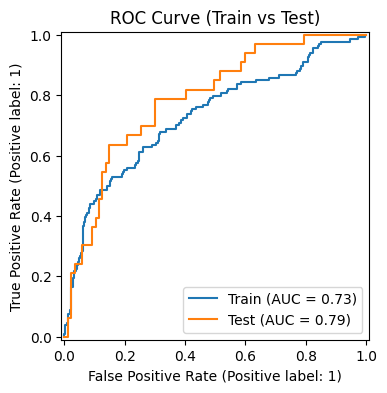

In [610]:
# lasso-selected features + balanced class weights
ridge_logreg = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')
ridge_logreg.fit(X_train_scaled[forward_features], y_train)
ridge_y_pred = ridge_logreg.predict(X_test_scaled[forward_features])
ridge_y_proba = ridge_logreg.predict_proba(X_test_scaled[forward_features])[:,1]
coef = pd.DataFrame({
    'feature': X_train_scaled[forward_features].columns,
    'coef': ridge_logreg.coef_[0],
    'odds_ratio': np.exp(ridge_logreg.coef_[0])
}).sort_values(by='odds_ratio', ascending=False)

print(coef)
full_model_report(y_test, ridge_y_pred, ridge_y_proba)
train_disp = skm.RocCurveDisplay.from_estimator(ridge_logreg, X_train_scaled[forward_features], y_train, name="Train")
skm.RocCurveDisplay.from_estimator(ridge_logreg, X_test_scaled[forward_features], y_test, ax=train_disp.ax_, name="Test")
plt.gcf().set_size_inches(10, 4)
plt.title("ROC Curve (Train vs Test)")
plt.show()

### Random Forest Feature Importance

Accuracy: 0.7333333333333333
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        87
           1       0.52      0.39      0.45        33

    accuracy                           0.73       120
   macro avg       0.65      0.63      0.64       120
weighted avg       0.72      0.73      0.72       120

                        feature  importance
17           age x credit_limit    0.094277
12                 payment_amt2    0.088828
10                     due_amt3    0.084739
8                      due_amt1    0.080511
16  latest_debt_to_credit_ratio    0.080401
5              payment_status_1    0.072545
4                           age    0.068107
9                      due_amt2    0.068037
0                  credit_limit    0.067481
13                 payment_amt3    0.062192
11                 payment_amt1    0.059883
6              payment_status_2    0.040068
7              payment_status_3    0.034643
15                     is_de

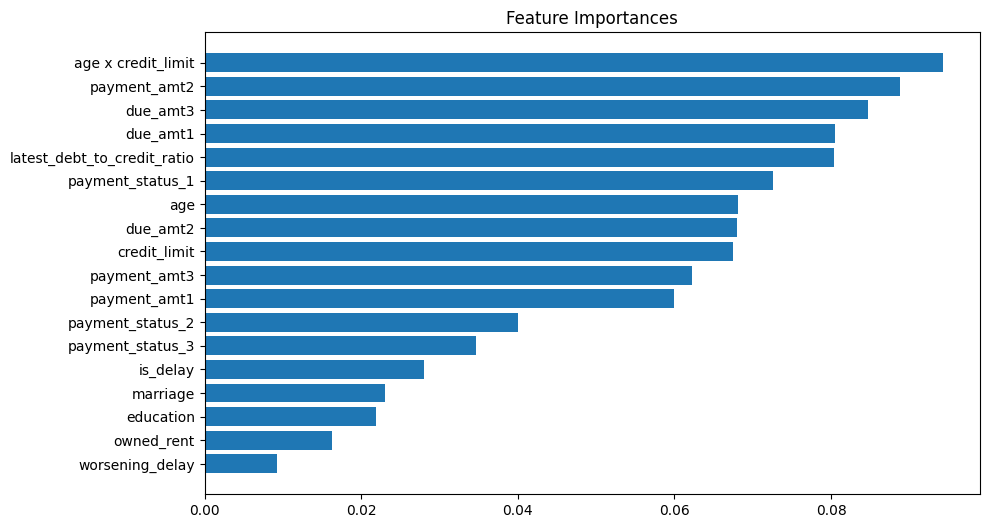

In [603]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

X = df.drop(columns=['default'])
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importances)
plt.figure(figsize=(10,6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.show()


['age x credit_limit', 'payment_amt2', 'latest_debt_to_credit_ratio', 'due_amt3', 'due_amt2', 'age', 'payment_status_1', 'due_amt1', 'credit_limit', 'payment_amt3', 'payment_amt1']
                        feature      coef  odds_ratio
6              payment_status_1  0.662242    1.939136
0            age x credit_limit  0.440472    1.553441
4                      due_amt2  0.400957    1.493252
3                      due_amt3  0.296067    1.344560
5                           age  0.021850    1.022091
9                  payment_amt3 -0.094550    0.909782
10                 payment_amt1 -0.114605    0.891718
2   latest_debt_to_credit_ratio -0.231705    0.793180
1                  payment_amt2 -0.415392    0.660082
7                      due_amt1 -0.503258    0.604558
8                  credit_limit -0.621755    0.537001
              precision    recall  f1-score   support

           0       0.79      0.93      0.85        87
           1       0.65      0.33      0.44        33

    acc

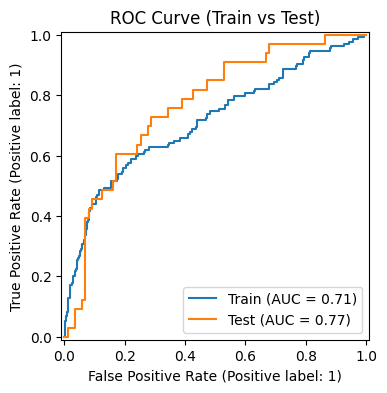

In [605]:
top_10_features = ['age x credit_limit', 'payment_amt2', 'latest_debt_to_credit_ratio', 'due_amt3', 'due_amt2', 'age', 'payment_status_1', 
                   'due_amt1', 'credit_limit', 'payment_amt3', 'payment_amt1']
top_10_idx = [X_train.columns.get_loc(f) for f in top_10_features]

X_train_top10 = X_train_scaled[:, top_10_idx]
X_test_top10 = X_test_scaled[:, top_10_idx]

rf_logreg = LogisticRegression(max_iter=10000, random_state=42)
rf_logreg.fit(X_train_top10, y_train)
rf_y_pred = rf_logreg.predict(X_test_top10)
rf_y_proba = rf_logreg.predict_proba(X_test_top10)[:,1]
coef = pd.DataFrame({
    'feature': top_10_features,
    'coef': rf_logreg.coef_[0],
    'odds_ratio': np.exp(rf_logreg.coef_[0])
}).sort_values(by='odds_ratio', ascending=False)

print(top_10_features)
print(coef)
full_model_report(y_test, rf_y_pred, rf_y_proba)
train_disp = skm.RocCurveDisplay.from_estimator(rf_logreg, X_train_top10, y_train, name="Train")
skm.RocCurveDisplay.from_estimator(rf_logreg, X_test_top10, y_test, ax=train_disp.ax_, name="Test")
plt.gcf().set_size_inches(10, 4)
plt.title("ROC Curve (Train vs Test)")
plt.show()